In [3]:
library(tidyverse)
library(ggpubr)
library(readr)
library(biomformat)
library(cowplot)
library(pROC)  
library(scales)
library(ggrepel)
library(patchwork)
library(ggpubr) 
library(ggsci)

### The correlation between SNE similarity and phylogenetic distance

In [6]:
table_group <- read.csv("data/tax_group.csv")
table_group$tax <- factor(table_group$tax, levels = c("Phylum", "Class", "Order", "Family", "Genus"), ordered = TRUE)


table_group <- table_group %>%
    group_by(tax) %>%
    mutate(
        r = cor(embed_cosine_mean, phy_dist_mean), # Pearson 
        slope = lm(phy_dist_mean ~ embed_cosine_mean)$coefficients[2], 
        intercept = lm(phy_dist_mean ~ embed_cosine_mean)$coefficients[1] 
    )
    
p1 <- ggplot(table_group, aes(x = embed_cosine_mean, y = phy_dist_mean)) +

    geom_errorbar(aes(ymin = phy_dist_mean - phy_dist_sd, ymax = phy_dist_mean + phy_dist_sd),
                  width = 0.02, color = "gray", linewidth = 0.3
    ) +
    geom_errorbarh(aes(xmin = embed_cosine_mean - embed_cosine_sd, xmax = embed_cosine_mean + embed_cosine_sd),
                   height = 0.02, color = "gray", linewidth = 0.3
    ) +
    geom_point(size = 2, alpha = 0.4, color = "blue") +
    geom_abline(aes(slope = slope, intercept = intercept), color = "red", linetype = "dashed", linewidth = 0.8) +
    geom_text(aes(x = 0.2, y = 1.5, label = paste0("r = ", round(r, 2))), size = 4, color = "black") +

    facet_wrap(~tax, nrow = 1) +

    labs(
        x = "SNE cosine",
        y = "Phylo distance",
        title = ""
    ) +

    theme_bw() +
    theme(
        legend.position = "top",
        plot.title = element_text(hjust = 0.5),
    )

`height` was translated to `width`.


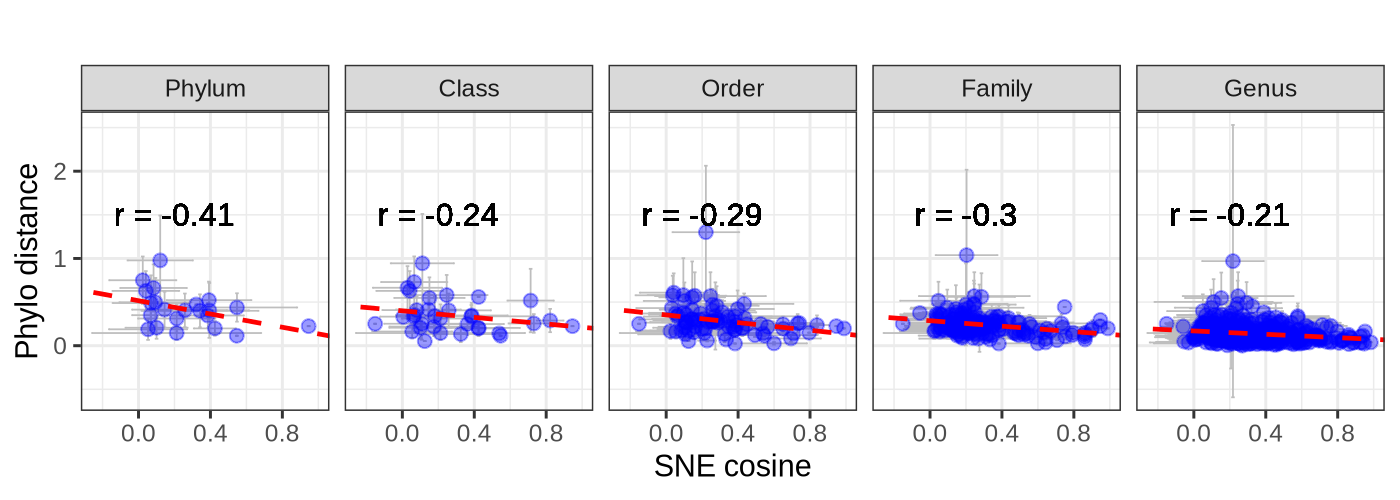

In [9]:
local({
  options(repr.plot.width = 7, repr.plot.height = 2.5, repr.plot.res = 200)
  print(p1)
})